# Telemetry Analysis

In [13]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot

importlib.reload(slipclassify)
importlib.reload(grid_sum)

<module 'Sliplib.GridSum' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_British_GP/notebooks/../../Sliplib/GridSum.py'>

In [14]:
# Select GP and Load Session
session = sl.load_gp(2025,"British Grand Prix","Race")
session.load()

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 43)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '27', '44', '1', '10', '18', '23', '14', '63', '87', '55', '31', 

In [15]:
# Define Contenders
Contenders = []

In [16]:
# Extract Lap Data
R_Laps = session.laps
R_Laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:55.042000,VER,1,0 days 00:01:45.820000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.707000,...,True,Red Bull Racing,0 days 00:56:09.003000,2025-07-06 14:03:49.616,12,1.0,False,,False,False
1,0 days 01:00:10.640000,VER,1,0 days 00:02:15.598000,2.0,1.0,NaT,NaT,0 days 00:00:45.755000,0 days 00:00:53.700000,...,True,Red Bull Racing,0 days 00:57:55.042000,2025-07-06 14:05:35.655,26,1.0,False,,False,False
2,0 days 01:02:27.997000,VER,1,0 days 00:02:17.357000,3.0,1.0,NaT,NaT,0 days 00:00:48.885000,0 days 00:00:50.924000,...,True,Red Bull Racing,0 days 01:00:10.640000,2025-07-06 14:07:51.253,6,1.0,False,,False,False
3,0 days 01:04:13.565000,VER,1,0 days 00:01:45.568000,4.0,1.0,NaT,NaT,0 days 00:00:36.223000,0 days 00:00:40.712000,...,True,Red Bull Racing,0 days 01:02:27.997000,2025-07-06 14:10:08.610,6712,1.0,False,,False,False
4,0 days 01:05:58.374000,VER,1,0 days 00:01:44.809000,5.0,1.0,NaT,NaT,0 days 00:00:31.996000,0 days 00:00:43.110000,...,True,Red Bull Racing,0 days 01:04:13.565000,2025-07-06 14:11:54.178,126,1.0,False,,False,False


In [17]:
# Import Drivers
hul,ver,nor,pia,lec,ham = slipclassify.pick_athletes(R_Laps,["HUL","VER","NOR","PIA","LEC","HAM"])

# Test
lec.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
179,0 days 00:58:21.200000,LEC,16,0 days 00:02:11.978000,1.0,1.0,0 days 00:56:24.191000,NaT,NaT,0 days 00:00:46.019000,...,True,Ferrari,0 days 00:56:09.003000,2025-07-06 14:03:49.616,126,15.0,False,,False,False
180,0 days 01:00:39.068000,LEC,16,0 days 00:02:17.868000,2.0,1.0,NaT,NaT,0 days 00:00:47.820000,0 days 00:00:53.895000,...,True,Ferrari,0 days 00:58:21.200000,2025-07-06 14:06:01.813,6,15.0,False,,False,False
181,0 days 01:02:54.940000,LEC,16,0 days 00:02:15.872000,3.0,1.0,NaT,NaT,0 days 00:00:45.563000,0 days 00:00:51.923000,...,True,Ferrari,0 days 01:00:39.068000,2025-07-06 14:08:19.681,671,15.0,False,,False,False
182,0 days 01:04:47.933000,LEC,16,0 days 00:01:52.993000,4.0,1.0,NaT,NaT,0 days 00:00:37.560000,0 days 00:00:42.616000,...,True,Ferrari,0 days 01:02:54.940000,2025-07-06 14:10:35.553,12,15.0,False,,False,True
183,0 days 01:06:46.391000,LEC,16,0 days 00:01:58.458000,5.0,1.0,NaT,NaT,0 days 00:00:35.369000,0 days 00:00:45.467000,...,True,Ferrari,0 days 01:04:47.933000,2025-07-06 14:12:28.546,126,15.0,True,TRACK LIMITS AT TURN 1 LAP 5,False,False
184,0 days 01:09:04.300000,LEC,16,0 days 00:02:17.909000,6.0,1.0,NaT,NaT,0 days 00:00:44.034000,0 days 00:00:55.199000,...,True,Ferrari,0 days 01:06:46.391000,2025-07-06 14:14:27.004,6,15.0,False,,False,False
185,0 days 01:10:56.842000,LEC,16,0 days 00:01:52.542000,7.0,1.0,NaT,NaT,0 days 00:00:40.420000,0 days 00:00:40.352000,...,True,Ferrari,0 days 01:09:04.300000,2025-07-06 14:16:44.913,671,15.0,False,,False,False
186,0 days 01:12:41.572000,LEC,16,0 days 00:01:44.730000,8.0,1.0,NaT,NaT,0 days 00:00:32.950000,0 days 00:00:39.590000,...,True,Ferrari,0 days 01:10:56.842000,2025-07-06 14:18:37.455,1,15.0,False,,False,True
187,0 days 01:14:22.513000,LEC,16,0 days 00:01:40.941000,9.0,1.0,NaT,NaT,0 days 00:00:32.265000,0 days 00:00:39.013000,...,True,Ferrari,0 days 01:12:41.572000,2025-07-06 14:20:22.185,1,15.0,False,,False,True
188,0 days 01:16:02.605000,LEC,16,0 days 00:01:40.092000,10.0,1.0,NaT,0 days 01:15:56.680000,0 days 00:00:31.426000,0 days 00:00:41.038000,...,True,Ferrari,0 days 01:14:22.513000,2025-07-06 14:22:03.126,1,13.0,False,,False,False


In [18]:
# Pick the fastest Lap for each
hul_fast,ver_fast,nor_fast,pia_fast,lec_fast,ham_fast = slipclassify.pick_fastest_group([hul,ver,nor,pia,lec,ham])

# Test
ver_fast

Time                      0 days 02:29:49.074000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:30.179000
LapNumber                                   49.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:28.994000
Sector2Time               0 days 00:00:36.792000
Sector3Time               0 days 00:00:24.393000
Sector1SessionTime        0 days 02:28:47.954000
Sector2SessionTime        0 days 02:29:24.746000
Sector3SessionTime        0 days 02:29:49.139000
SpeedI1                                    297.0
SpeedI2                                    266.0
SpeedFL                                    255.0
SpeedST                                    318.0
IsPersonalBest                              True
Compound                                  MEDIUM
TyreLife            

In [19]:
# Take out a Summary!
fast_sum = slipclassify.tel_fast_lap_summary([hul_fast,ver_fast,nor_fast,pia_fast,lec_fast,ham_fast])
fast_sum

,Driver,LapTime,Compound,TyreLife
0,HUL,1:30.933,MEDIUM,9.0
1,VER,1:30.179,MEDIUM,8.0
2,NOR,1:29.734,MEDIUM,4.0
3,PIA,1:29.337,MEDIUM,8.0
4,LEC,1:30.819,SOFT,11.0
5,HAM,1:30.016,SOFT,11.0


## Telemetry Datas and Graphs

In [20]:
# Get Telemetry Datas
hul_tel,ver_tel,nor_tel,pia_tel,lec_tel,ham_tel = slipclassify.tel_get_for_all([hul_fast,ver_fast,nor_fast,pia_fast,lec_fast,ham_fast])

# Test
lec_tel

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
0,2025-07-06 15:37:56.633,10722.0,262.0,7,100.0,False,0,car,0 days 00:00:00.266000,0 days 02:30:16.020000,19.358889
1,2025-07-06 15:37:56.834,10624.0,264.0,7,100.0,False,0,car,0 days 00:00:00.467000,0 days 02:30:16.221000,34.098889
2,2025-07-06 15:37:57.034,10744.0,267.0,7,100.0,False,0,car,0 days 00:00:00.667000,0 days 02:30:16.421000,48.932222
3,2025-07-06 15:37:57.474,10976.0,273.0,7,100.0,False,0,car,0 days 00:00:01.107000,0 days 02:30:16.861000,82.298889
4,2025-07-06 15:37:57.754,11127.0,277.0,7,100.0,False,0,car,0 days 00:00:01.387000,0 days 02:30:17.141000,103.843333
...,...,...,...,...,...,...,...,...,...,...,...
329,2025-07-06 15:39:25.994,10938.0,234.0,6,100.0,False,0,car,0 days 00:01:29.627000,0 days 02:31:45.381000,5733.359167
330,2025-07-06 15:39:26.274,11090.0,236.0,6,100.0,False,0,car,0 days 00:01:29.907000,0 days 02:31:45.661000,5751.714722
331,2025-07-06 15:39:26.674,11396.0,248.0,6,100.0,False,0,car,0 days 00:01:30.307000,0 days 02:31:46.061000,5779.270278
332,2025-07-06 15:39:26.954,11542.0,254.0,6,100.0,False,0,car,0 days 00:01:30.587000,0 days 02:31:46.341000,5799.025833


### Plot - 1 (Distance vs Speed)
This part has 2 Plots:
- One for the 2 Contenders
- Other for the Top 4

### HUL VS OCO

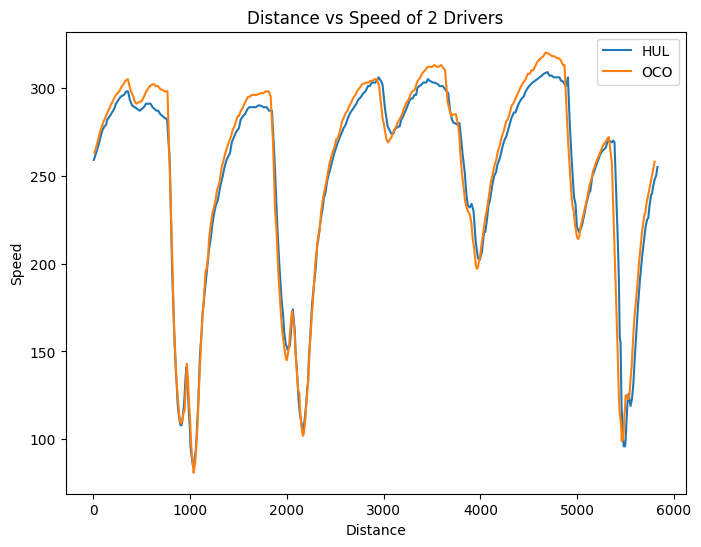

In [21]:
slplot.plot_dist_speed([hul_tel,ver_tel],["HUL","OCO"])

Pretty much distance change is observed between HUL and OCO. Purely HUL dominates and shows an Eye-Witness for such a position Gain

#### Top 4 Plot

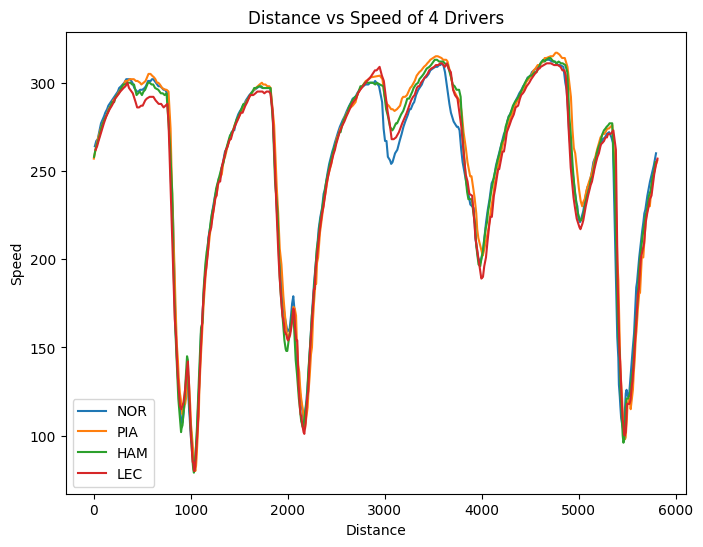

In [22]:
slplot.plot_dist_speed([nor_tel,pia_tel,ham_tel,lec_tel],["NOR","PIA","HAM","LEC"])

From the above Graph! Piastri Has an advantage! He has made the Fastest Lap among the Contenders!

### Plot - 2 (Distance vs Brake)

### HUL vs OCO

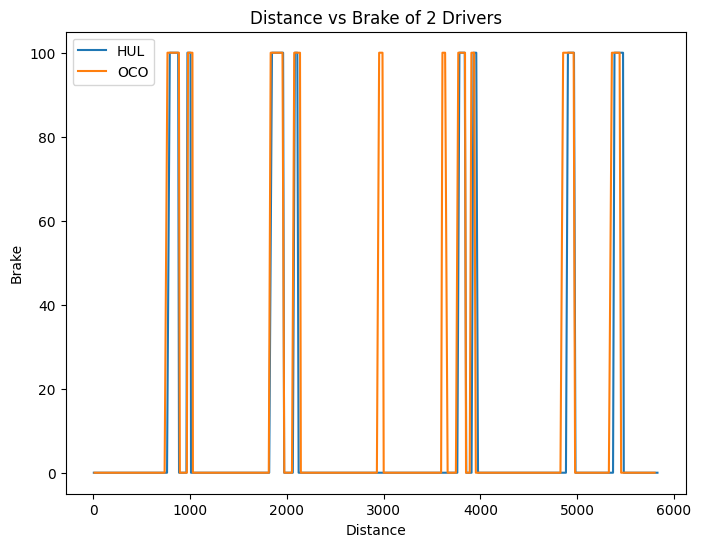

In [23]:
slplot.plot_dist_brake([hul_tel,oco_tel],["HUL","OCO"])

### Top - 4 Plot

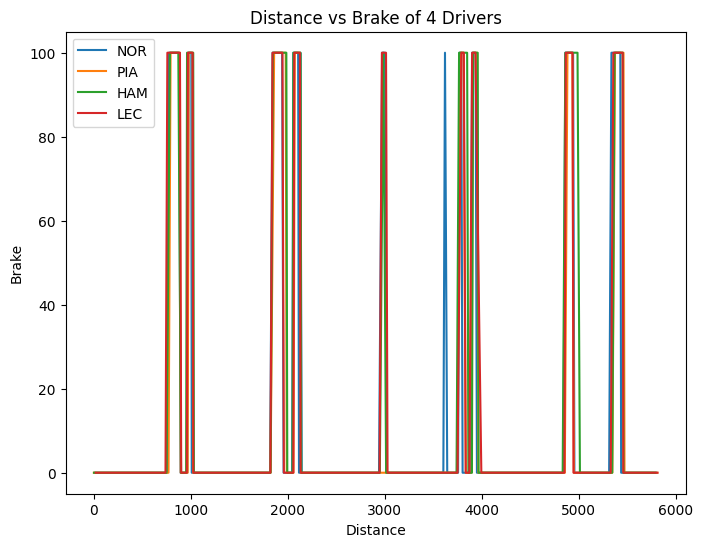

In [24]:
slplot.plot_dist_brake([nor_tel,pia_tel,ham_tel,lec_tel],["NOR","PIA","HAM","LEC"])